# Bang-Bang Cost Matrix Visualization

Heatmaps and diagnostics for the minimum-transition-time matrix $\mathbf{C}^{BB}$ and its derivatives:

- $\mathbf{W}$ — free-window budget (`SegmentEvents.W`, computed in `events.py`)
- $\mathbf{C}^{BB}$ — bang-bang minimum transition time (`cost.py`)
- $\mathbf{S} = \mathbf{W} - \mathbf{C}$ — slack (diagnostic)
- $\mathbf{\Phi} = (\max\{0, -\mathbf{S}\})^2$ — infeasibility penalty (design objective, §4.1)

Reference: `docs/Per-Segment Synchronization Slack.md`, `docs/Buffer minimum-time cost.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.analysis.cost import compute_C_bb, compute_S_bb, compute_Phi_bb

## Run simulation and compute cost matrices

In [2]:
config_path = Path("../configs/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)

print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}, solver={cfg.get('solver', 'scurve')}")
print(f"j_max = {cfg['jmax']}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

events = result.segment_events
j_max = cfg['jmax']

bb = compute_C_bb(events, j_max)
W = events.W
C = bb.C
S = compute_S_bb(events, j_max)
Phi = compute_Phi_bb(events, j_max)

print(f"\nMatrix shapes: W={W.shape}, C={C.shape}, S={S.shape}, Phi={Phi.shape}")
print(f"W range: [{W.min():.4f}, {W.max():.4f}] s")
print(f"C range: [{C.min():.4f}, {C.max():.4f}] s  (all finite: {np.all(np.isfinite(C))})")
print(f"S range: [{S.min():.4f}, {S.max():.4f}] s  (negative cells: {int((S < 0).sum())} / {S.size})")
print(f"Phi total: {Phi.sum():.4f} s^2")

Config: batch=100, n_buffer_seg=6, solver=quintic
j_max = 100.0

Matrix shapes: W=(99, 6), C=(99, 6), S=(99, 6), Phi=(99, 6)
W range: [-0.2147, 0.4521] s
C range: [0.0077, 0.2667] s  (all finite: True)
S range: [-0.3502, 0.3366] s  (negative cells: 386 / 594)
Phi total: 10.5452 s^2


## Heatmap: $\mathbf{C}^{BB}$ — minimum transition time

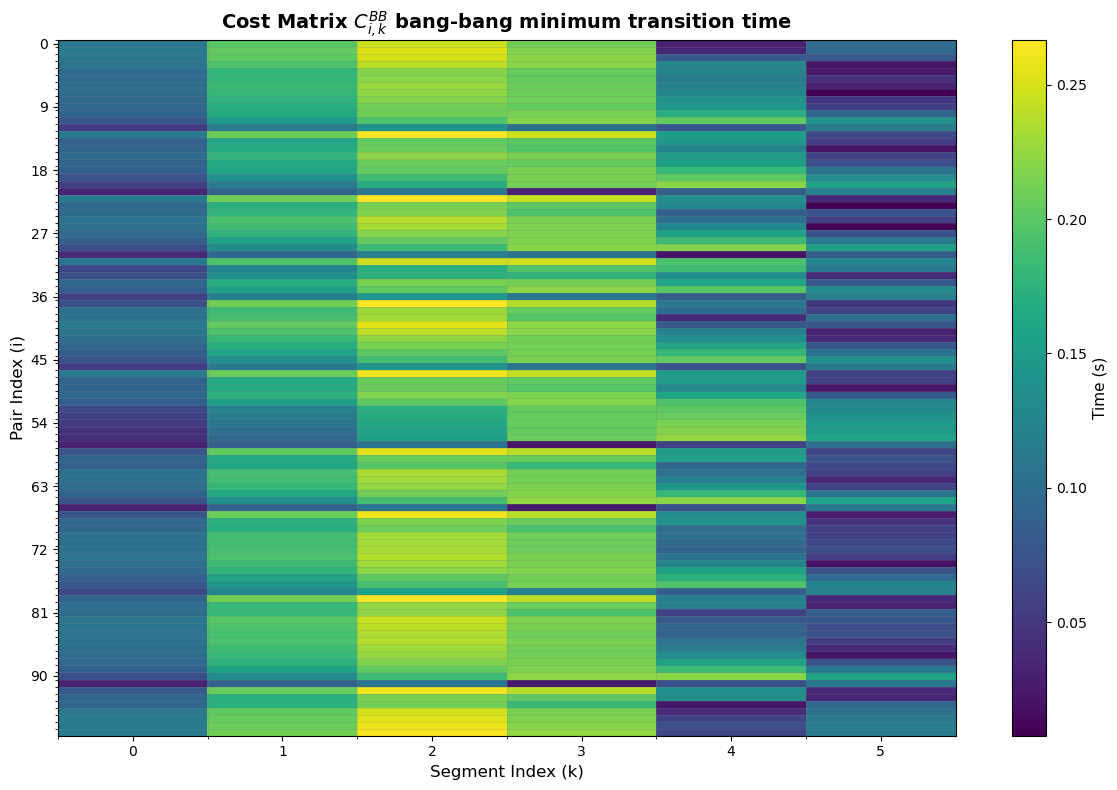

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(C, cmap="viridis", aspect="auto", interpolation="nearest")
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title(r"Cost Matrix $C^{BB}_{i,k}$ bang-bang minimum transition time", fontsize=14, fontweight="bold")
ax.set_xticks(np.arange(C.shape[1]))
ax.set_yticks(np.arange(0, C.shape[0], max(1, C.shape[0] // 10)))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (s)", fontsize=11)
ax.set_xticks(np.arange(C.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(C.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

## Heatmap: $\mathbf{S} = \mathbf{W} - \mathbf{C}$ (slack)

Zero-centred diverging colormap. Green = margin, red = infeasible.

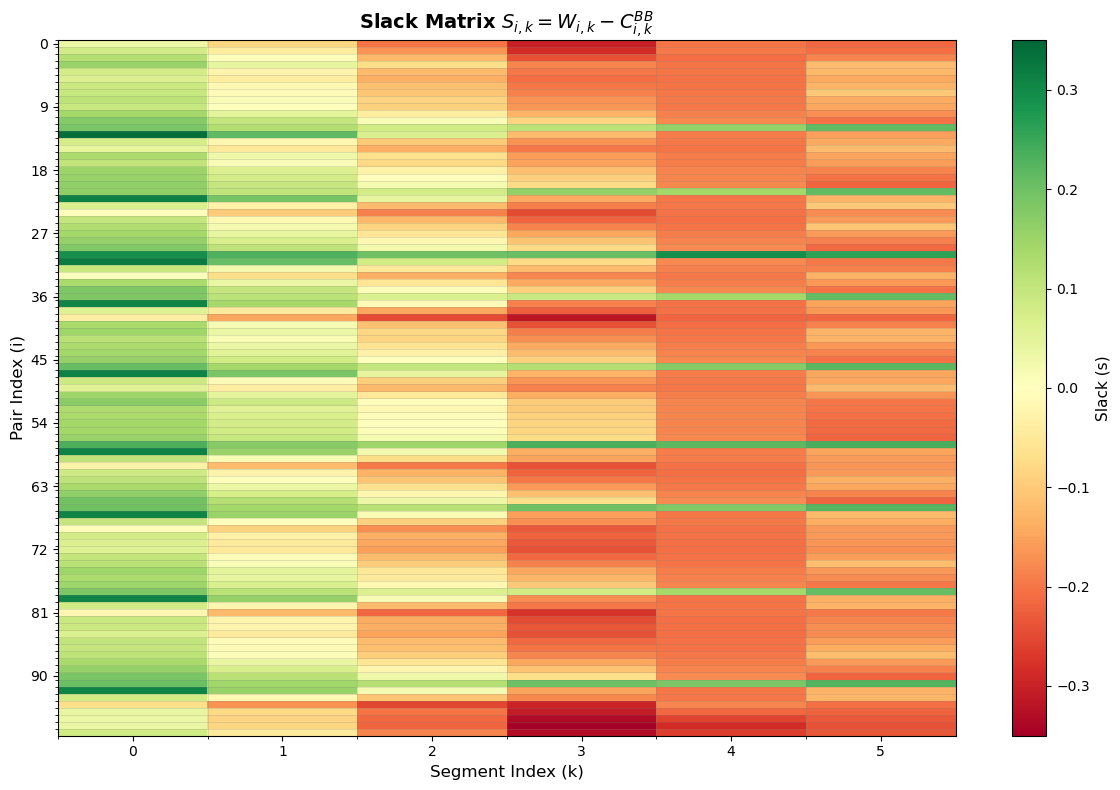

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
v = float(np.abs(S).max())
im = ax.imshow(S, cmap="RdYlGn", aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title(r"Slack Matrix $S_{i,k} = W_{i,k} - C^{BB}_{i,k}$", fontsize=14, fontweight="bold")
ax.set_xticks(np.arange(S.shape[1]))
ax.set_yticks(np.arange(0, S.shape[0], max(1, S.shape[0] // 10)))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Slack (s)", fontsize=11)
ax.set_xticks(np.arange(S.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(S.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

## Heatmap: $\mathbf{\Phi} = (\max\{0, C - W\})^2$ (infeasibility penalty)

Zero on feasible cells; grows quadratically in the overlap region.

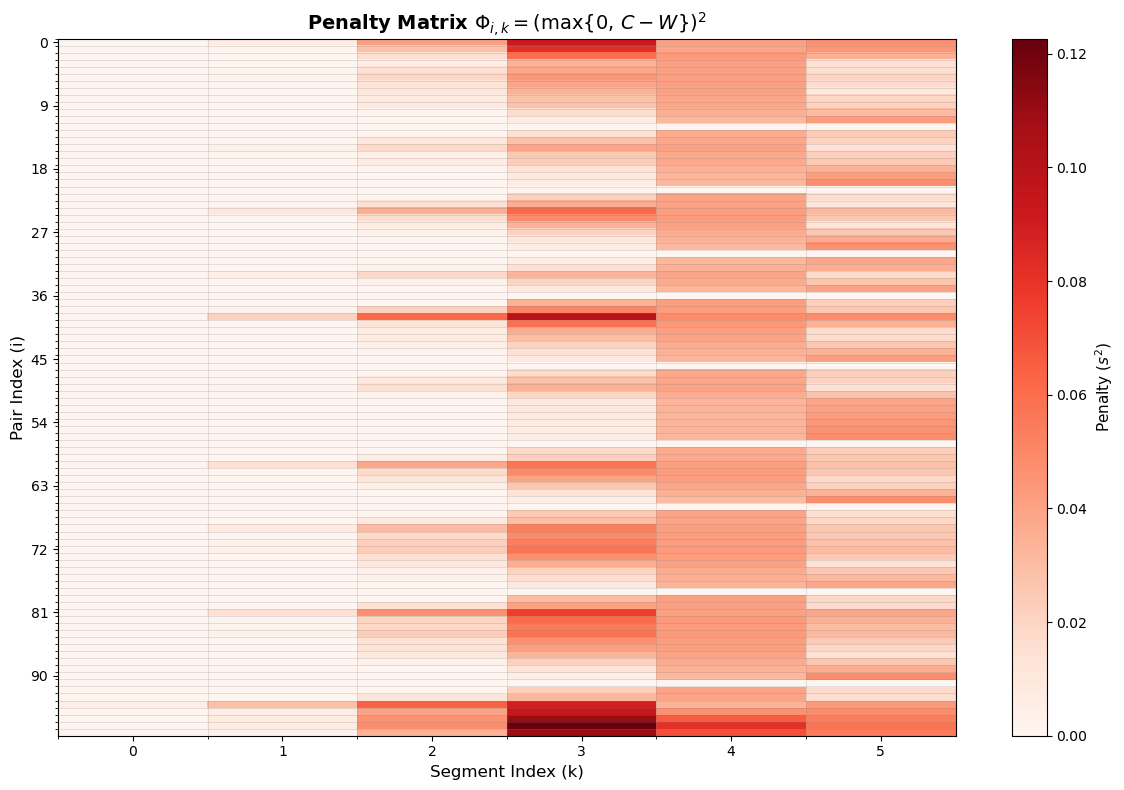

Phi_total = 10.545187 s^2
Infeasible cells (Phi > 0): 386 / 594


In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(Phi, cmap="Reds", aspect="auto", interpolation="nearest")
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title(r"Penalty Matrix $\Phi_{i,k} = (\max\{0,\, C - W\})^2$", fontsize=14, fontweight="bold")
ax.set_xticks(np.arange(Phi.shape[1]))
ax.set_yticks(np.arange(0, Phi.shape[0], max(1, Phi.shape[0] // 10)))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"Penalty ($s^2$)", fontsize=11)
ax.set_xticks(np.arange(Phi.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(Phi.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Phi_total = {Phi.sum():.6f} s^2")
print(f"Infeasible cells (Phi > 0): {int((Phi > 0).sum())} / {Phi.size}")

## W, C, S side-by-side

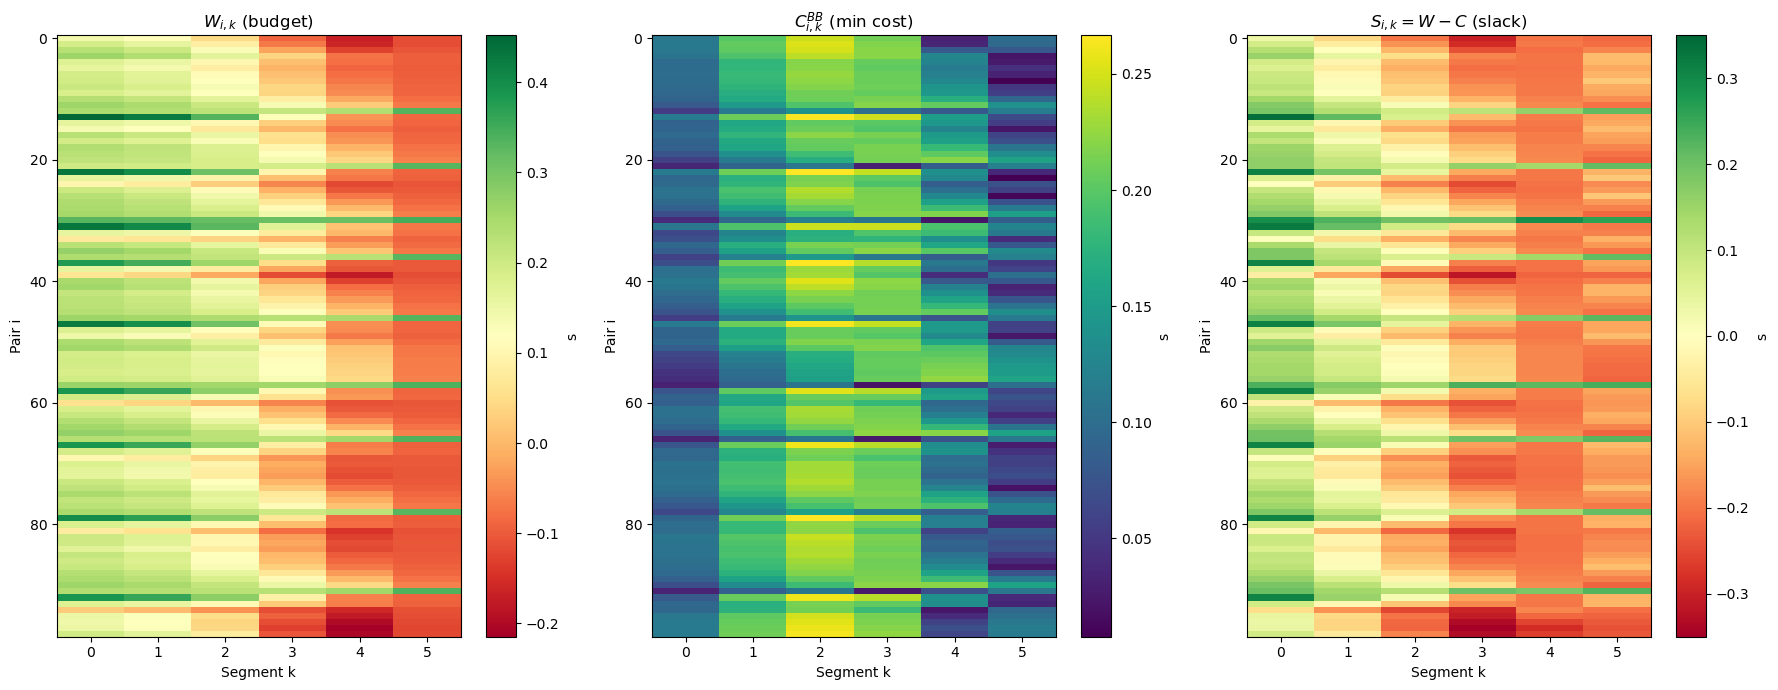

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

vmax_time = max(W.max(), C.max())
vmin_time = min(W.min(), 0.0)

im0 = axes[0].imshow(W, cmap="RdYlGn", aspect="auto", vmin=vmin_time, vmax=vmax_time)
axes[0].set_title(r"$W_{i,k}$ (budget)")
axes[0].set_xlabel("Segment k")
axes[0].set_ylabel("Pair i")
plt.colorbar(im0, ax=axes[0], label="s")

im1 = axes[1].imshow(C, cmap="viridis", aspect="auto")
axes[1].set_title(r"$C^{BB}_{i,k}$ (min cost)")
axes[1].set_xlabel("Segment k")
axes[1].set_ylabel("Pair i")
plt.colorbar(im1, ax=axes[1], label="s")

v_s = float(np.abs(S).max())
im2 = axes[2].imshow(S, cmap="RdYlGn", aspect="auto", vmin=-v_s, vmax=v_s)
axes[2].set_title(r"$S_{i,k} = W - C$ (slack)")
axes[2].set_xlabel("Segment k")
axes[2].set_ylabel("Pair i")
plt.colorbar(im2, ax=axes[2], label="s")

plt.tight_layout()
plt.show()

## Per-segment profile (edge-concentration diagnostic, §3.4)

The formalization predicts that edge segments ($k=0$ and $k=N^B-1$) run hotter — higher $C$, lower $S$ — because one boundary is pinned externally (upstream at $k=0$, registrar at $k=N^B-1$).

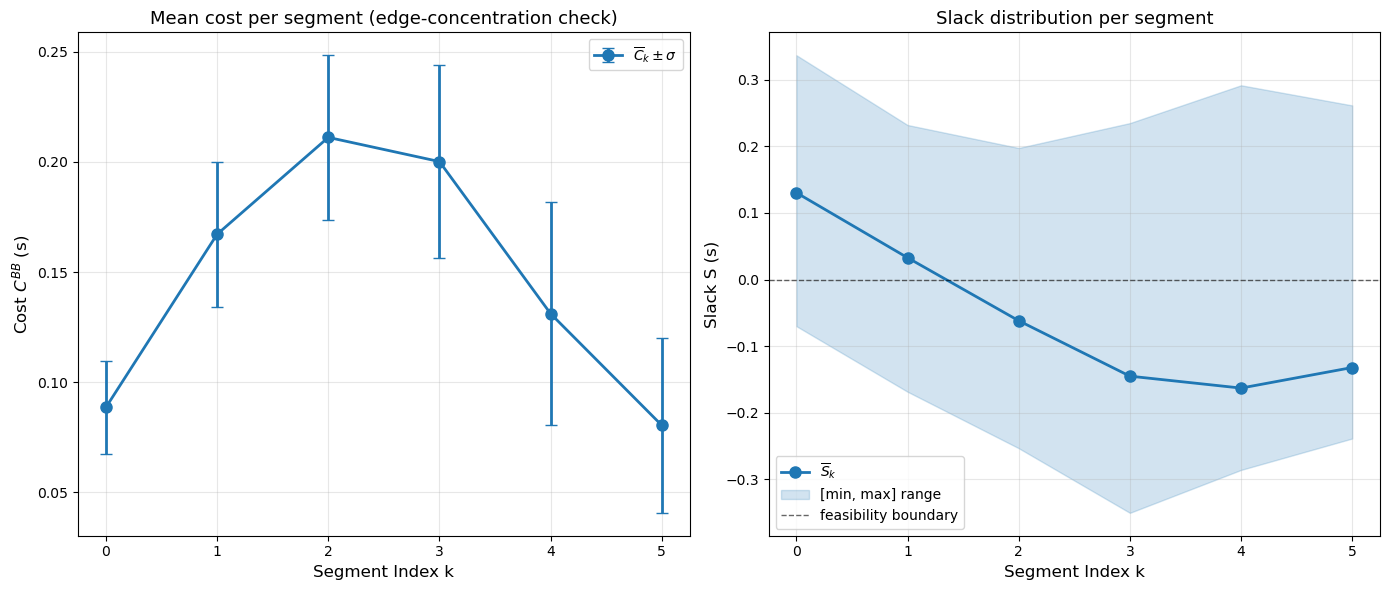

Per-segment summary (hot = high C, cold = low S):
  k     mean C      max C     mean S      min S   % infeas
  0    0.08867    0.11585    0.13027   -0.07006       4.0%
  1    0.16720    0.21101    0.03270   -0.16846      39.4%
  2    0.21116    0.26666   -0.06187   -0.25321      73.7%
  3    0.20018    0.24692   -0.14506   -0.35022      90.9%
  4    0.13114    0.22430   -0.16297   -0.28581      90.9%
  5    0.08048    0.15917   -0.13209   -0.23865      90.9%


In [7]:
N_B = C.shape[1]
k = np.arange(N_B)

C_mean = C.mean(axis=0)
C_std = C.std(axis=0)
S_mean = S.mean(axis=0)
S_min = S.min(axis=0)
S_max = S.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].errorbar(k, C_mean, yerr=C_std, marker="o", capsize=4, linewidth=2, markersize=8, label=r"$\overline{C}_k \pm \sigma$")
axes[0].set_xlabel("Segment Index k", fontsize=12)
axes[0].set_ylabel(r"Cost $C^{BB}$ (s)", fontsize=12)
axes[0].set_title("Mean cost per segment (edge-concentration check)", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(k, S_mean, marker="o", linewidth=2, markersize=8, label=r"$\overline{S}_k$", color="C0")
axes[1].fill_between(k, S_min, S_max, alpha=0.2, color="C0", label="[min, max] range")
axes[1].axhline(0, color="k", linestyle="--", linewidth=1, alpha=0.6, label="feasibility boundary")
axes[1].set_xlabel("Segment Index k", fontsize=12)
axes[1].set_ylabel("Slack S (s)", fontsize=12)
axes[1].set_title("Slack distribution per segment", fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Per-segment summary (hot = high C, cold = low S):")
print(f"{'k':>3} {'mean C':>10} {'max C':>10} {'mean S':>10} {'min S':>10} {'% infeas':>10}")
for kk in range(N_B):
    pct = 100.0 * (S[:, kk] < 0).mean()
    print(f"{kk:>3} {C_mean[kk]:>10.5f} {C[:, kk].max():>10.5f} {S_mean[kk]:>10.5f} {S_min[kk]:>10.5f} {pct:>9.1f}%")

## Per-pair profile of $C^{BB}$ across segments

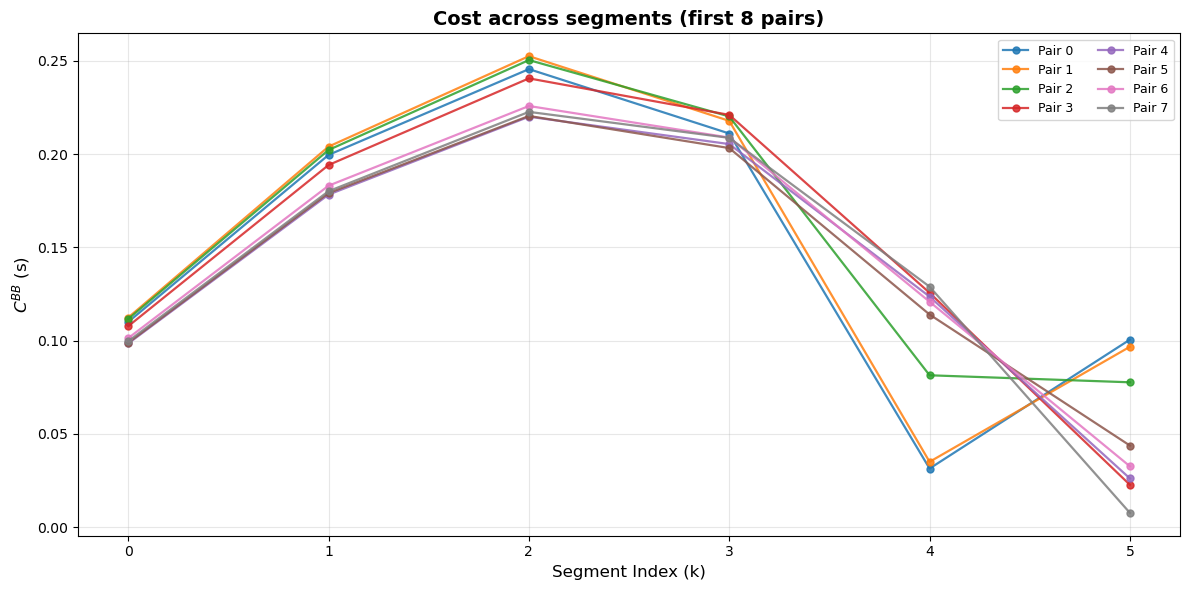

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for i in range(min(8, C.shape[0])):
    ax.plot(C[i, :], marker="o", label=f"Pair {i}", linewidth=1.6, markersize=5, alpha=0.85)
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel(r"$C^{BB}$ (s)", fontsize=12)
ax.set_title("Cost across segments (first 8 pairs)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## Case breakdown: up vs down vs infeasible

Case breakdown (594 cells):
  up   (+1):    525 ( 88.4%)
  down (-1):     69 ( 11.6%)
  infeas(0):      0 (  0.0%)


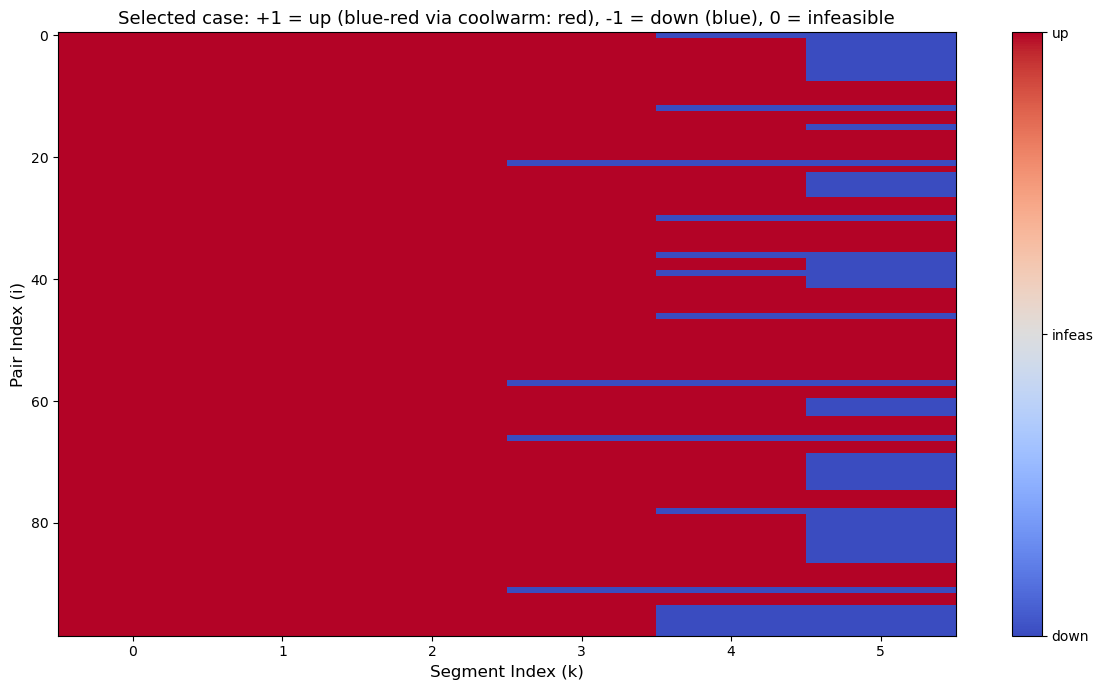

In [9]:
case = bb.case
n_up = int((case == 1).sum())
n_down = int((case == -1).sum())
n_infeas = int((case == 0).sum())
total = case.size

print(f"Case breakdown ({total} cells):")
print(f"  up   (+1): {n_up:>6} ({100.0 * n_up / total:5.1f}%)")
print(f"  down (-1): {n_down:>6} ({100.0 * n_down / total:5.1f}%)")
print(f"  infeas(0): {n_infeas:>6} ({100.0 * n_infeas / total:5.1f}%)")

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(case, cmap="coolwarm", aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title("Selected case: +1 = up (blue-red via coolwarm: red), -1 = down (blue), 0 = infeasible", fontsize=13)
cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(["down", "infeas", "up"])
plt.tight_layout()
plt.show()

## Peak acceleration check (§5.4 sentinel)

The jerk-only-bound assumption requires $|a_p| \le a^B_\max$. If any cell exceeds this, the derivation breaks and the 3-phase (acceleration-saturated) extension is needed.

Peak |a_p| across all cells: 11.3831 m/s^2
Buffer A_max: 8.5000 m/s^2
Cells exceeding A_max: 168 / 594
Headroom (A_max - max|a_p|): -2.8831 m/s^2


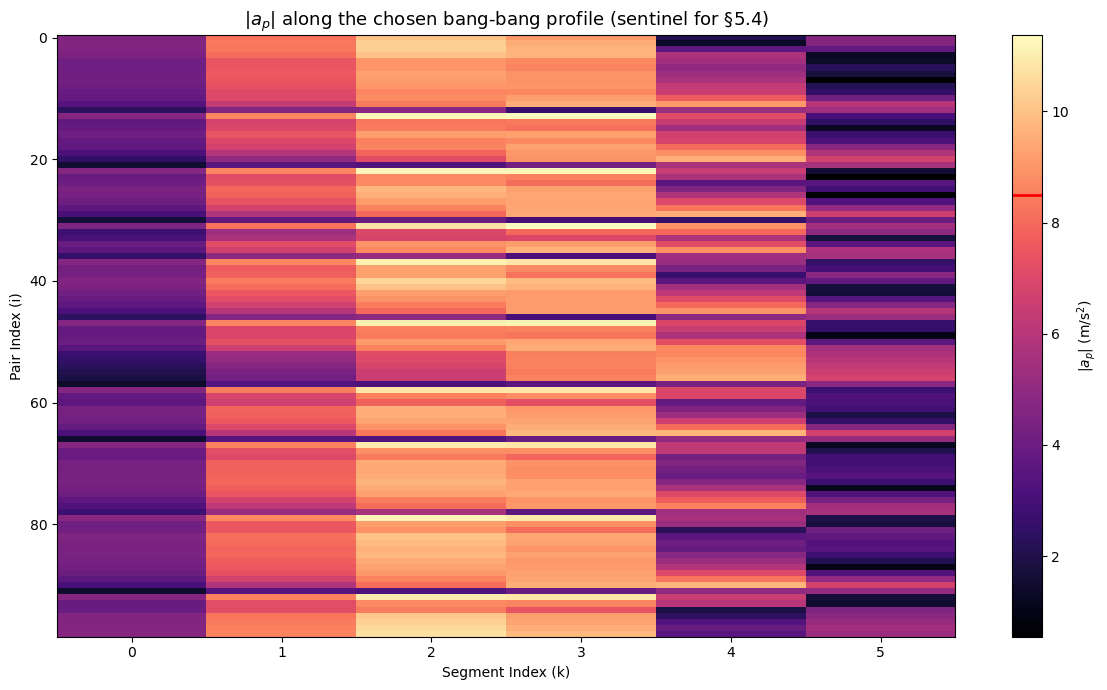

In [10]:
a_peak_abs = np.abs(bb.a_peak)
A_max = cfg["Amax"]

print(f"Peak |a_p| across all cells: {a_peak_abs.max():.4f} m/s^2")
print(f"Buffer A_max: {A_max:.4f} m/s^2")
print(f"Cells exceeding A_max: {int((a_peak_abs > A_max).sum())} / {a_peak_abs.size}")
print(f"Headroom (A_max - max|a_p|): {A_max - a_peak_abs.max():.4f} m/s^2")

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(a_peak_abs, cmap="magma", aspect="auto", interpolation="nearest")
ax.set_xlabel("Segment Index (k)")
ax.set_ylabel("Pair Index (i)")
ax.set_title(r"$|a_p|$ along the chosen bang-bang profile (sentinel for §5.4)", fontsize=13)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$|a_p|$ (m/s$^2$)")
cbar.ax.axhline(A_max, color="red", linewidth=2)
plt.tight_layout()
plt.show()

## Unit check: zero-BC reduction

For $a^- = a^+ = 0$, the closed form reduces to $C = 2\sqrt{|\Delta v| / j_{\max}}$ (doc §4.1). Verify against `compute_C_bb` over a sweep.

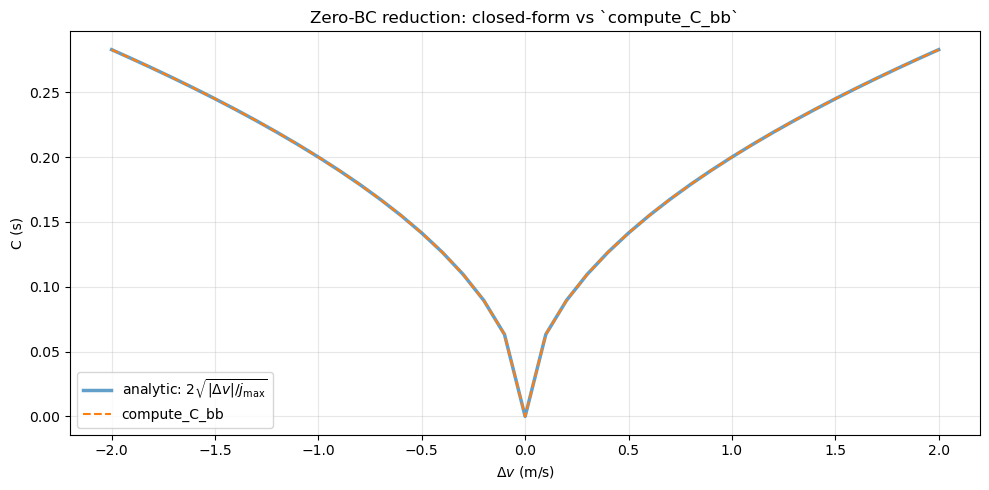

Max abs error vs closed form: 5.551e-17
OK: numeric matches closed form to 1e-12.


In [11]:
from ksb.analysis.events import SegmentEvents

dv_sweep = np.linspace(-2.0, 2.0, 41)
v_minus = np.zeros_like(dv_sweep).reshape(1, -1)
v_plus = dv_sweep.reshape(1, -1)
a_zero = np.zeros((1, dv_sweep.size))
t_zero = np.zeros_like(a_zero)

synth = SegmentEvents(
    t_out=t_zero, t_in=t_zero,
    v_minus=v_minus, a_minus=a_zero,
    v_plus=v_plus, a_plus=a_zero,
)

j = cfg["jmax"]
res = compute_C_bb(synth, j)

C_analytic = 2.0 * np.sqrt(np.abs(dv_sweep) / j)
C_numeric = res.C.ravel()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dv_sweep, C_analytic, linewidth=2.5, alpha=0.7, label=r"analytic: $2\sqrt{|\Delta v|/j_{\max}}$")
ax.plot(dv_sweep, C_numeric, linestyle="--", linewidth=1.5, label="compute_C_bb")
ax.set_xlabel(r"$\Delta v$ (m/s)")
ax.set_ylabel("C (s)")
ax.set_title("Zero-BC reduction: closed-form vs `compute_C_bb`")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

max_err = float(np.max(np.abs(C_analytic - C_numeric)))
print(f"Max abs error vs closed form: {max_err:.3e}")
assert max_err < 1e-12, "Closed-form reduction failed"
print("OK: numeric matches closed form to 1e-12.")

## Summary statistics

In [12]:
print("Cost Matrix Summary")
print("=" * 60)
print(f"Shape          : {C.shape} (pairs x segments)")
print(f"j_max          : {j_max}")
print()
print(f"W   min/mean/max: {W.min():>10.5f} / {W.mean():>10.5f} / {W.max():>10.5f} s")
print(f"C   min/mean/max: {C.min():>10.5f} / {C.mean():>10.5f} / {C.max():>10.5f} s")
print(f"S   min/mean/max: {S.min():>10.5f} / {S.mean():>10.5f} / {S.max():>10.5f} s")
print()
print(f"Negative-slack cells : {int((S < 0).sum()):>6} / {S.size} ({100.0 * (S < 0).mean():.1f}%)")
print(f"Infeasible cells (C=inf): {int(~np.isfinite(C).all()):>6}")
print(f"Phi_total            : {Phi.sum():.6f} s^2")
print(f"Phi_max (worst cell) : {Phi.max():.6f} s^2")

Cost Matrix Summary
Shape          : (99, 6) (pairs x segments)
j_max          : 100.0

W   min/mean/max:   -0.21474 /    0.08997 /    0.45209 s
C   min/mean/max:    0.00769 /    0.14647 /    0.26666 s
S   min/mean/max:   -0.35022 /   -0.05650 /    0.33664 s

Negative-slack cells :    386 / 594 (65.0%)
Infeasible cells (C=inf):      0
Phi_total            : 10.545187 s^2
Phi_max (worst cell) : 0.122653 s^2
